In [1]:
import audiotools as at
from audiotools import AudioSignal
from pathlib import Path
from typing import Union, List, Optional, Tuple, Iterable, Dict
import torch
import numpy as np


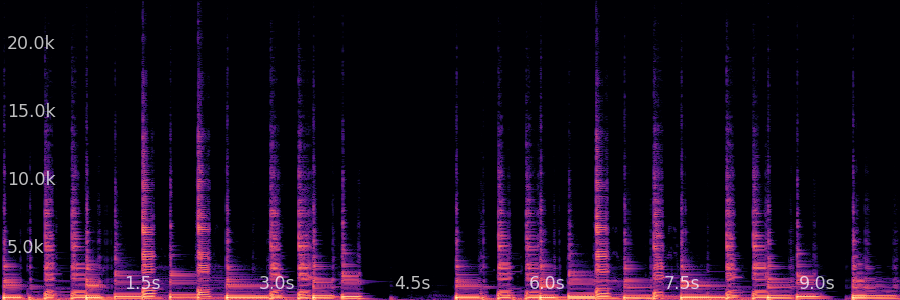
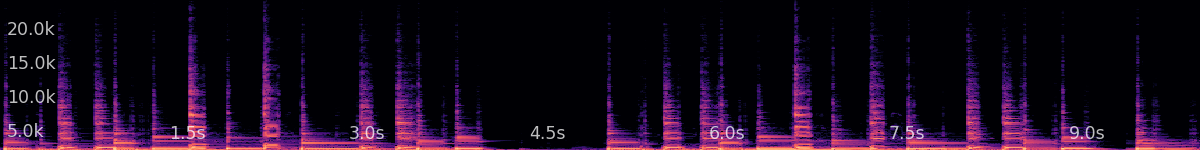

In [2]:
audio_path = Path("/home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav")
audio_sig = AudioSignal(audio_path)
audio_sig.widget()


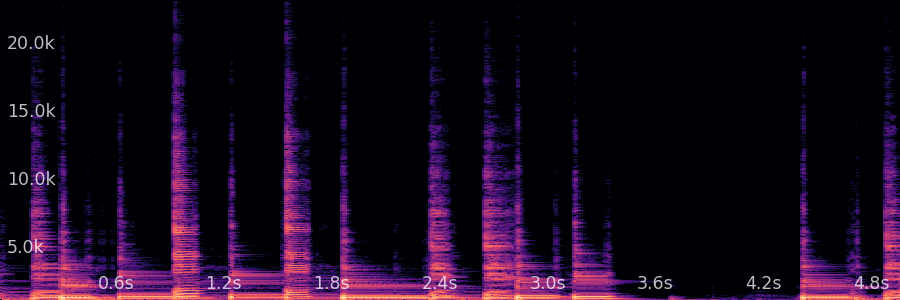
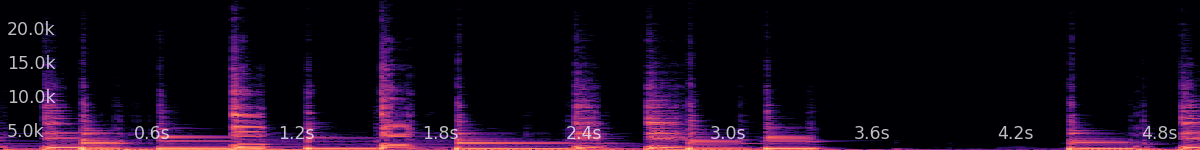

In [3]:
x = AudioSignal.salient_excerpt(audio_path, duration=5).to_mono().resample(44100).ensure_max_of_audio()
x.widget()

In [4]:
print(x)

duration: 5.000 seconds
batch_size: 1
path: /tmp/tmpugxdn5c3.wav
sample_rate: 44100
num_channels: 1
audio_data.shape: torch.Size([1, 1, 220500])
stft_params: STFTParams(window_length=2048, hop_length=512, window_type='hann', match_stride=False, padding_type='reflect')
device: cpu



In [5]:
x_at_path = x.path_to_input_file
# x_prime = AudioSignal.salient_excerpt(x_at_path, duration=2)

In [6]:
tmp_dir = Path('/tmp/')
tmp_dir.exists()

True

In [7]:
def preprocess_audio(audio_path_or_array: Union[torch.Tensor, str, Path, np.ndarray, AudioSignal], salient_excerpt: Optional[int] = None, sample_rate: Optional[int] = None) -> AudioSignal:
    #audio can be filename or AudioSignal; if tensor, must provide sample_rate
    if isinstance(audio_path_or_array, (str, Path)):
        if salient_excerpt:
            return AudioSignal.salient_excerpt(audio_path_or_array, duration=3).to_mono().resample(SAMPLE_RATE).ensure_max_of_audio()
        else:
            return AudioSignal(audio_path_or_array).to_mono().resample(SAMPLE_RATE).ensure_max_of_audio()

    elif isinstance(audio_path_or_array, AudioSignal):
        if salient_excerpt:
            return audio_path_or_array.to_mono().resample(SAMPLE_RATE).ensure_max_of_audio().truncate_samples(SAMPLE_RATE * salient_excerpt)
        else:
            return audio_path_or_array.to_mono().resample(SAMPLE_RATE).ensure_max_of_audio()#.normalize(-24)
    elif isinstance(audio_path_or_array, (torch.Tensor, np.ndarray)):
        if sample_rate is None:
            raise ValueError("Must provide sample_rate if input is a tensor or ndarray")
        if salient_excerpt:
            return AudioSignal(audio_path_or_array, sample_rate).to_mono().resample(SAMPLE_RATE).ensure_max_of_audio().truncate_samples(SAMPLE_RATE * salient_excerpt)#.normalize(-24)
        else:
            return AudioSignal(audio_path_or_array, sample_rate).to_mono().resample(SAMPLE_RATE).ensure_max_of_audio()#.normalize(-24)
    else: 
        raise ValueError("not audiosignal, tensor, str, path or array")


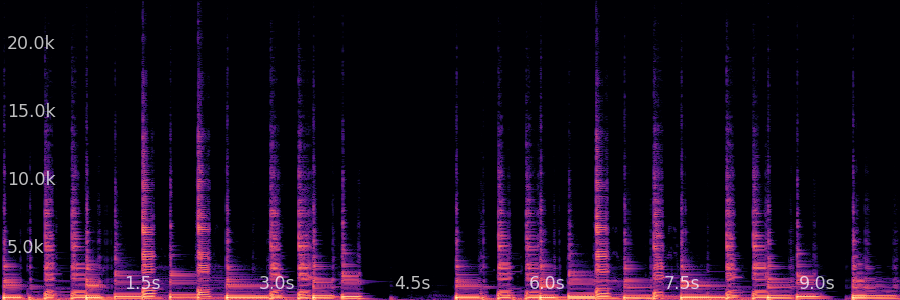
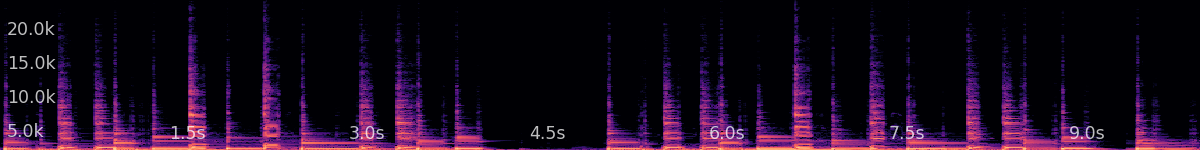

In [8]:
#testing new function
SAMPLE_RATE=44_100
path_all = preprocess_audio(audio_path)
path_all.widget()


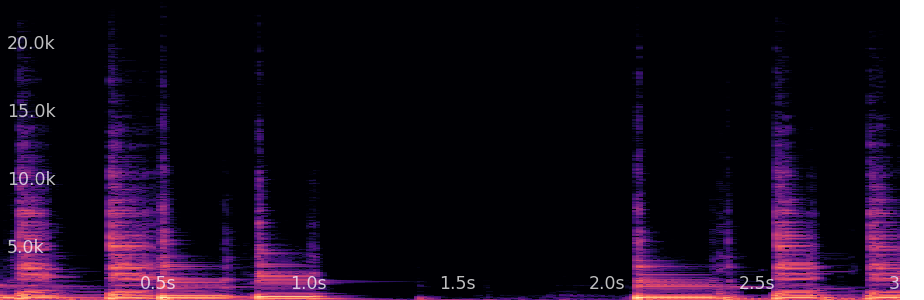
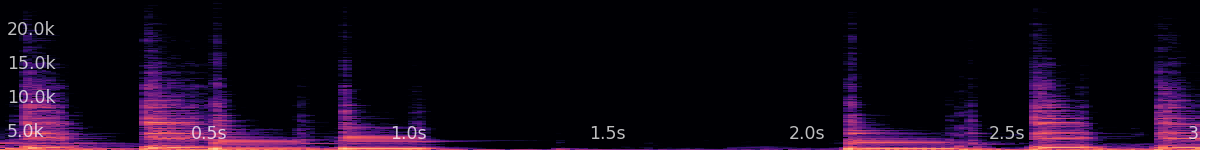

In [9]:
path_short = preprocess_audio(audio_path, 3)
path_short.widget()


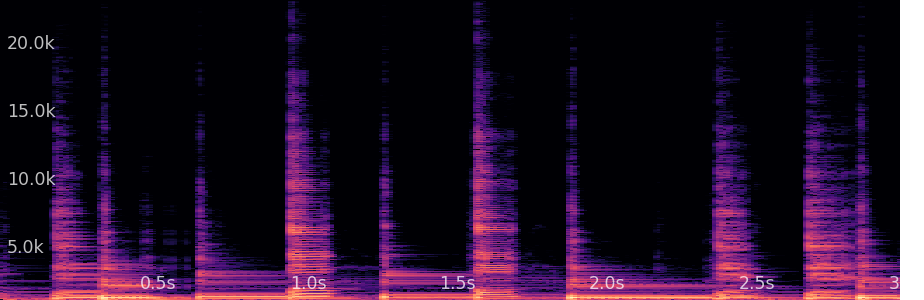
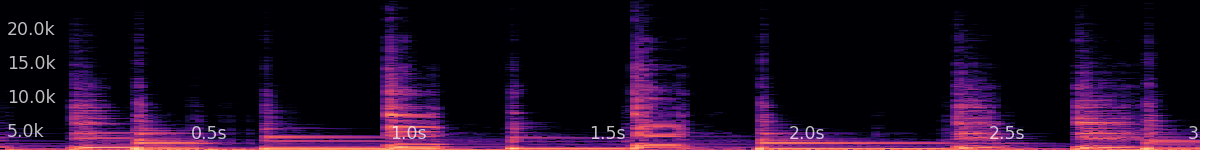

In [10]:
x_short = preprocess_audio(x, 3)
x_short.widget()

In [11]:
x_array = AudioSignal(torch.randn(5*44100), 44100)
print(x_array)

x_array_prime = preprocess_audio(x_array, 3)
print(x_array_prime)

duration: 5.000 seconds
batch_size: 1
path: path unknown
sample_rate: 44100
num_channels: 1
audio_data.shape: torch.Size([1, 1, 220500])
stft_params: STFTParams(window_length=2048, hop_length=512, window_type='hann', match_stride=False, padding_type='reflect')
device: cpu

duration: 3.000 seconds
batch_size: 1
path: path unknown
sample_rate: 44100
num_channels: 1
audio_data.shape: torch.Size([1, 1, 132300])
stft_params: STFTParams(window_length=2048, hop_length=512, window_type='hann', match_stride=False, padding_type='reflect')
device: cpu



In [35]:
#mon 2/17 it works!

import numpy as np
from audiotools import AudioSignal
import typing
# import util
import numbers

def random_state(seed: typing.Union[int, np.random.RandomState]):
    """
    Turn seed into a np.random.RandomState instance.

    Parameters
    ----------
    seed : typing.Union[int, np.random.RandomState] or None
        If seed is None, return the RandomState singleton used by np.random.
        If seed is an int, return a new RandomState instance seeded with seed.
        If seed is already a RandomState instance, return it.
        Otherwise raise ValueError.

    Returns
    -------
    np.random.RandomState
        Random state object.

    Raises
    ------
    ValueError
        If seed is not valid, an error is thrown.
    """
    if seed is None or seed is np.random:
        return np.random.mtrand._rand
    elif isinstance(seed, (numbers.Integral, np.integer, int)):
        return np.random.RandomState(seed)
    elif isinstance(seed, np.random.RandomState):
        return seed
    else:
        raise ValueError(
            "%r cannot be used to seed a numpy.random.RandomState" " instance" % seed
        )

def at_excerpt(signal: AudioSignal,
            offset: float = None,
            duration: float = None,
            state: typing.Union[np.random.RandomState, int] = None):
    signal = signal.clone()
    total_duration = signal.duration
    # print(duration, total_duration)
    state = random_state(state)
    # print(state)
    lower_bound = 0 if offset is None else offset
    upper_bound = max(total_duration - duration, 0)
    offset = state.uniform(lower_bound, upper_bound)

    # print(signal.audio_data)
        # Convert offset and duration to number of samples
    offset_samples = int(offset * signal.sample_rate)
    # print(offset_samples)
    duration_samples = int(duration * signal.sample_rate)
    # print(duration_samples)

    # cropped_audio = audio_data[:, :, offset_samples:offset_samples + duration_samples]

    signal.audio_data = signal.audio_data[..., offset_samples:offset_samples + duration_samples]
    # # signal = AudioSignal(sig.samples, sig.sample_rate,offset=offset, duration=duration)
    # print(signal)
    signal.metadata["offset"] = offset
    signal.metadata["duration"] = duration
    return signal

def salient_excerpt(
        sig: AudioSignal,
        duration: int, 
        loudness_cutoff: float = None,
        num_tries: int = 8,
        state: typing.Union[np.random.RandomState, int] = None):

    state = random_state(state)
    if loudness_cutoff is None:
        excerpt = at_excerpt(sig, duration=duration, state=state)
    else:
        loudness = -np.inf
        num_try = 0
        while loudness <= loudness_cutoff:
            excerpt = at_excerpt(sig, duration=duration, state=state)
            loudness = excerpt.loudness()
            num_try += 1
            if num_tries is not None and num_try >= num_tries:
                break
    return excerpt



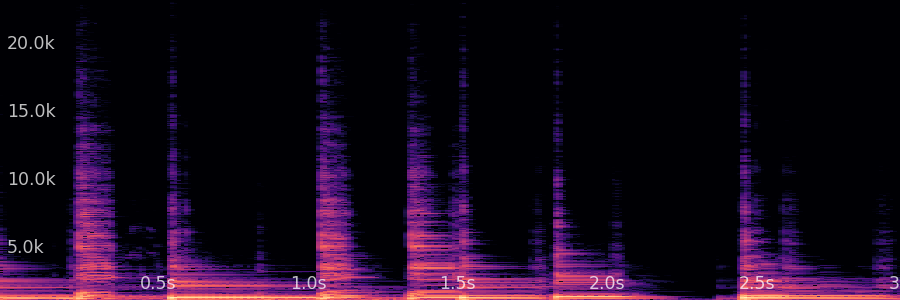
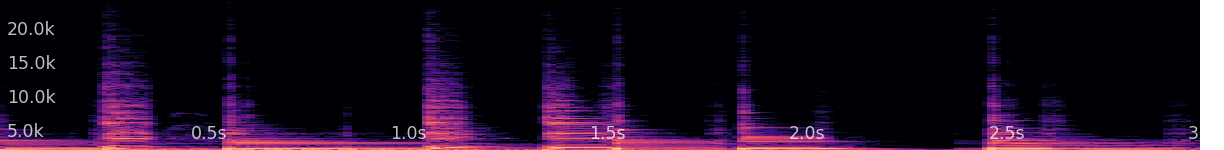

In [36]:
path_all = preprocess_audio(audio_path)
path_short = at_excerpt(path_all, offset=7, duration=3)

# path_short = at_excerpt(path_all, duration=3)
path_short.widget()




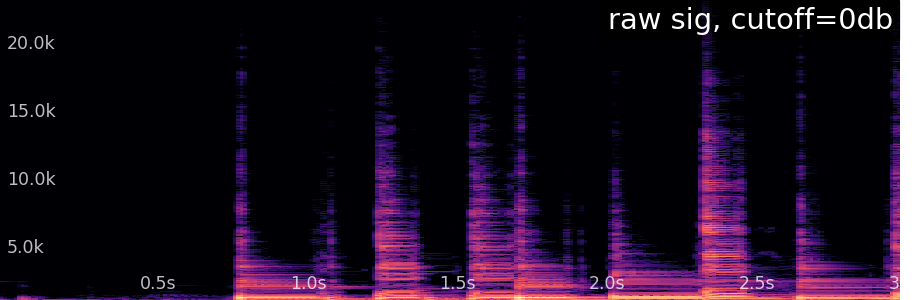
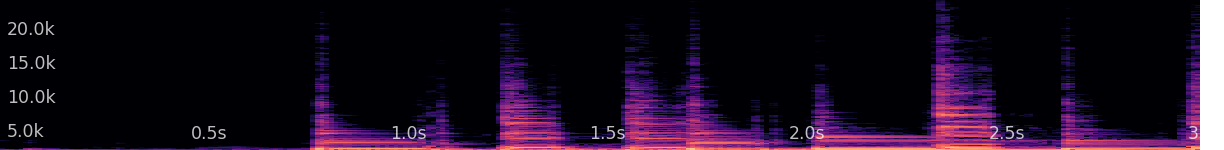


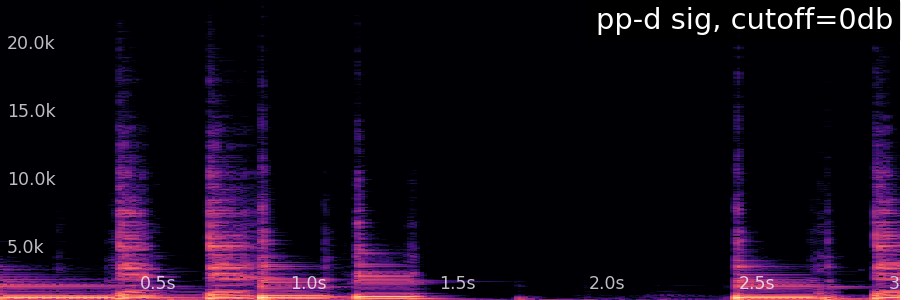
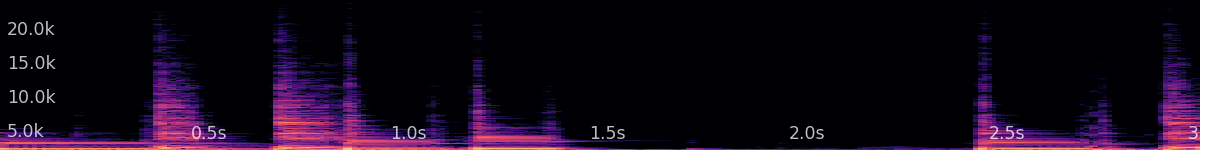


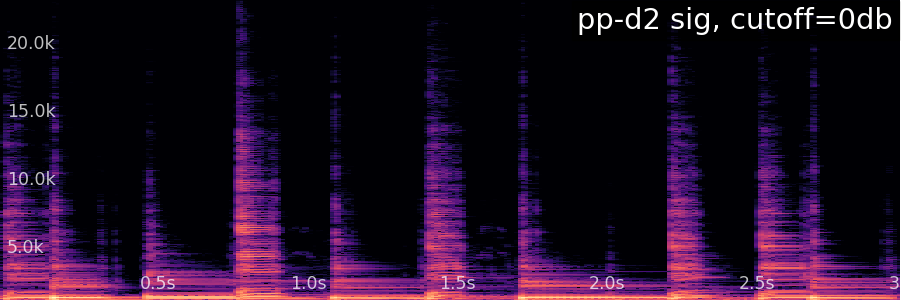
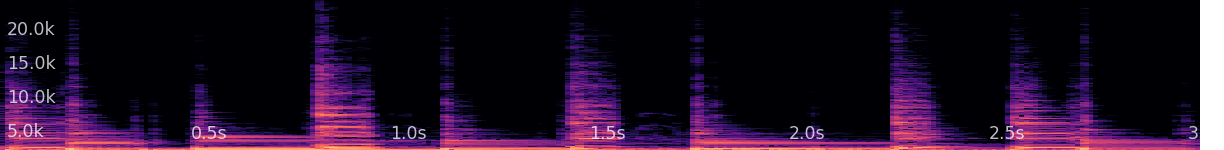

In [42]:
# path_all = preprocess_audio(audio_path)

#no preprocessing before 
path_all = AudioSignal(audio_path)
path_short = salient_excerpt(path_all, duration=3, loudness_cutoff=0)
path_short.widget(title='raw sig, cutoff=0db')

path_pp = preprocess_audio(audio_path)
path_short_ = salient_excerpt(path_pp, duration=3, loudness_cutoff=0)
path_short_.widget(title='pp-d sig, cutoff=0db')


path_pp2 = preprocess_audio(audio_path)
path_short_2 = salient_excerpt(path_pp2, duration=3, loudness_cutoff=0)
path_short_2.widget(title='pp-d2 sig, cutoff=0db')

In [14]:
path_all.sample_rate
len(path_all.samples)
print(path_all.samples)
print(path_all)

tensor([[[ 0.0007,  0.0007,  0.0007,  ..., -0.0021, -0.0020, -0.0020]]])
duration: 10.000 seconds
batch_size: 1
path: /home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav
sample_rate: 44100
num_channels: 1
audio_data.shape: torch.Size([1, 1, 441000])
stft_params: STFTParams(window_length=2048, hop_length=512, window_type='hann', match_stride=False, padding_type='reflect')
device: cpu



In [49]:
def clone_sig(audio_path: Union[str, Path],
              descriptions_source: Union[str, List[str]]):
    sig = AudioSignal(audio_path)
    
    signal_list = [sig for _ in range(len(descriptions_source))]
    signal = AudioSignal.batch(signal_list)
    print(signal)

clone_sig(audio_path, ["warm", "cold", "happy"])

duration: 10.000 seconds
batch_size: 3
path: [PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav'), PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav'), PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav')]
sample_rate: 44100
num_channels: 1
audio_data.shape: torch.Size([3, 1, 441000])
stft_params: STFTParams(window_length=2048, hop_length=512, window_type='hann', match_stride=False, padding_type='reflect')
device: cpu



In [52]:
def load_examples(dir_path: Union[str,Path]) -> List[Path]:
    dir_path = Path(dir_path)  # Convert string to Path if necessary
    exts = ["mp3", "wav", "flac"]
    example_files = [list(dir_path.rglob(f"*.{e}")) for e in exts]
    example_files = sum(example_files, [])  # Trick to flatten list of lists
    return example_files
load_examples(audio_path.parent)

[PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/vocals.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/drums.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/guitar.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/piano.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav')]

In [53]:
def load_examples(dir_path: Union[str, Path]) -> List[Path]:
    dir_path = Path(dir_path)  # Convert string to Path if necessary
    
    if dir_path.is_file():  # If it's a single file, return it as a list
        return [dir_path]
    
    exts = ["mp3", "wav", "flac"]
    example_files = [list(dir_path.rglob(f"*.{e}")) for e in exts]
    example_files = sum(example_files, [])  # Trick to flatten list of lists
    return example_files
load_examples(audio_path)
load_examples(audio_path.parent)

[PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/vocals.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/drums.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/guitar.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/piano.wav'),
 PosixPath('/home/annie/research/text2fx/assets/multistem_examples/10s/bass.wav')]

In [ ]:
def wavs_to_batch(samples: Union[str, Path, List[str], List[Path]]) -> AudioSignal:
    if isinstance(samples, (str, Path)):
        all_raw_sigs = load_examples(samples)
    else:
        samples = [Path(s) if isinstance(s, str) else s for s in samples]
        all_raw_sigs = samples
    
    signal_list = [preprocess_audio(raw_sig_i) for raw_sig_i in all_raw_sigs]
    return AudioSignal.batch(signal_list)

